# Autoencoder with Early Stopping

Retrains the AE using all frames (no sample limit) and early stopping on test loss.

## Setup

In [1]:
from pathlib import Path
from datetime import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break
if STUDENT is None:
    raise RuntimeError("Could not find Student root")

FRAMES_ROOT = STUDENT / "data" / "frames"
RUNS_ROOT = STUDENT / "runs"

stamp = datetime.now().strftime("%d%m%Y_%H%M%S")
AE_RUN_DIR = RUNS_ROOT / "autoencoder" / f"autoencoder_{stamp}"
AE_RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Frames:", FRAMES_ROOT)
print("Run dir:", AE_RUN_DIR.name)

Device: mps
Frames: /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/data/frames
Run dir: autoencoder_28042026_222428


## Hyperparameters

In [2]:
Z_DIM = 64
EPOCHS = 100
BATCH_SIZE = 128
LR = 3e-4
GRAD_CLIP = 1.0
LOG_EVERY = 100
TEST_RATIO = 0.2
SEED = 42

# Early stopping
PATIENCE = 10
MIN_DELTA = 1e-4

## Dataset

In [3]:
def load_episode(video_dir: Path):
    frames = sorted(video_dir.glob("*.png"), key=lambda p: int(p.stem))
    xs = [
        torch.tensor(np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0)
        for p in frames
    ]
    return torch.stack(xs).unsqueeze(1)

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
episodes = [load_episode(video_dir) for video_dir in video_dirs]

rng = np.random.default_rng(SEED)
indices = np.arange(len(episodes))
rng.shuffle(indices)

n_test = int(np.ceil(TEST_RATIO * len(episodes)))
test_idx = set(indices[:n_test].tolist())
train_idx = set(indices[n_test:].tolist())

ae_train_dataset = torch.cat([episodes[i] for i in range(len(episodes)) if i in train_idx], dim=0)
ae_test_dataset = torch.cat([episodes[i] for i in range(len(episodes)) if i in test_idx], dim=0)

AE_TRAIN_PT = AE_RUN_DIR / "ae_train_dataset.pt"
AE_TEST_PT = AE_RUN_DIR / "ae_test_dataset.pt"
torch.save(ae_train_dataset, AE_TRAIN_PT)
torch.save(ae_test_dataset, AE_TEST_PT)

ae_train_dataloader = DataLoader(ae_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
ae_test_dataloader = DataLoader(ae_test_dataset, shuffle=False, batch_size=BATCH_SIZE)

print(f"Train: {len(ae_train_dataset)} frames, Test: {len(ae_test_dataset)} frames")
print(f"No sample limit - using all frames")

Train: 132189 frames, Test: 32557 frames
No sample limit - using all frames


## Loss

In [4]:
def weighted_mse(x_hat, x, threshold=0.1, high_weight=20.0):
    mask = (x > threshold).float()
    weights = 1.0 + mask * high_weight
    return ((x_hat - x) ** 2 * weights).mean()

## Model

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(25600, z_dim),
            nn.LayerNorm(z_dim),
        )
        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84], z

    def decode(self, z):
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84]

ae_model = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
opt = torch.optim.Adam(ae_model.parameters(), lr=LR)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f"AutoEncoder: {total_params:,} parameters")

AutoEncoder: 5,051,073 parameters


## Train with Early Stopping

In [6]:
ae_train_losses = []
ae_test_losses = []
best_test_loss = float("inf")
best_state = None
epochs_no_improve = 0
stopped_epoch = EPOCHS
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    ae_model.train()
    train_ep_loss = 0.0
    train_n_b = 0

    for step, batch in enumerate(ae_train_dataloader, start=1):
        x = batch.to(DEVICE, non_blocking=True)
        x_hat, _ = ae_model(x)
        loss = weighted_mse(x_hat, x)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae_model.parameters(), GRAD_CLIP)
        opt.step()

        train_ep_loss += float(loss.item())
        train_n_b += 1

    ae_model.eval()
    test_ep_loss = 0.0
    test_n_b = 0

    with torch.no_grad():
        for batch in ae_test_dataloader:
            x = batch.to(DEVICE, non_blocking=True)
            x_hat, _ = ae_model(x)
            loss = weighted_mse(x_hat, x)
            test_ep_loss += float(loss.item())
            test_n_b += 1

    train_mean = train_ep_loss / max(train_n_b, 1)
    test_mean = test_ep_loss / max(test_n_b, 1)
    ae_train_losses.append(train_mean)
    ae_test_losses.append(test_mean)

    improved = test_mean < best_test_loss - MIN_DELTA
    if improved:
        best_test_loss = test_mean
        best_state = {k: v.cpu().clone() for k, v in ae_model.state_dict().items()}
        epochs_no_improve = 0
        marker = " *best*"
    else:
        epochs_no_improve += 1
        marker = f" (no improve {epochs_no_improve}/{PATIENCE})"

    print(
        f"[AE] epoch {epoch:03d}/{EPOCHS} "
        f"train {train_mean:.6f} | test {test_mean:.6f}{marker} "
        f"| {time.time() - t0:.1f}s"
    )

    if epochs_no_improve >= PATIENCE:
        stopped_epoch = epoch
        print(f"\n[AE] Early stopping at epoch {epoch} (best test loss: {best_test_loss:.6f})")
        break

# Restore best weights
if best_state is not None:
    ae_model.load_state_dict(best_state)
    ae_model.to(DEVICE)
    print(f"[AE] Restored best model (test loss: {best_test_loss:.6f})")

[AE] epoch 001/100 train 0.025512 | test 0.011078 *best* | 149.4s


[AE] epoch 002/100 train 0.003161 | test 0.011021 (no improve 1/10) | 311.4s


[AE] epoch 003/100 train 0.002377 | test 0.013031 (no improve 2/10) | 470.3s


[AE] epoch 004/100 train 0.001978 | test 0.011671 (no improve 3/10) | 615.3s


[AE] epoch 005/100 train 0.001819 | test 0.012726 (no improve 4/10) | 758.7s


...

[AE] epoch 007/100 train 0.001392 | test 0.014977 (no improve 6/10) | 1058.7s


[AE] epoch 008/100 train 0.001306 | test 0.013977 (no improve 7/10) | 1206.4s


[AE] epoch 009/100 train 0.001248 | test 0.014108 (no improve 8/10) | 1338.7s


[AE] epoch 010/100 train 0.001255 | test 0.014106 (no improve 9/10) | 1488.3s


[AE] epoch 011/100 train 0.001058 | test 0.014998 (no improve 10/10) | 1642.5s

[AE] Early stopping at epoch 11 (best test loss: 0.011078)
[AE] Restored best model (test loss: 0.011078)


## Save

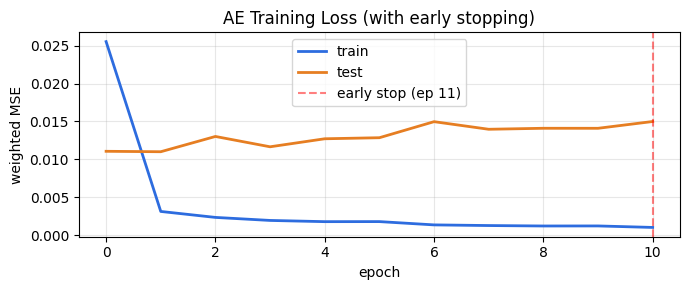

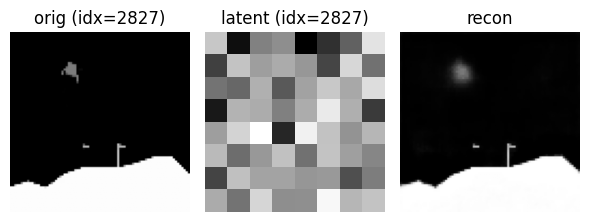


All artifacts saved to /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/autoencoder/autoencoder_28042026_222428
Stopped at epoch 11, best test loss: 0.011078


In [7]:
torch.save(ae_model.state_dict(), AE_RUN_DIR / "model.pth")
torch.save(ae_model, AE_RUN_DIR / "model_full.pt")
torch.save({"ae_train_losses": ae_train_losses, "ae_test_losses": ae_test_losses}, AE_RUN_DIR / "losses.pt")

ae_model.eval()
ae_model_cpu = ae_model.to("cpu")
scripted_ae = torch.jit.script(ae_model_cpu)
scripted_ae.save(str(AE_RUN_DIR / "ae_model_scripted.pt"))
ae_model = ae_model_cpu.to(DEVICE)

# Loss plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ae_train_losses, color="#2d6cdf", lw=2, label="train")
ax.plot(ae_test_losses, color="#e67e22", lw=2, label="test")
if stopped_epoch < EPOCHS:
    ax.axvline(stopped_epoch - 1, color="red", ls="--", alpha=0.5, label=f"early stop (ep {stopped_epoch})")
ax.set_xlabel("epoch")
ax.set_ylabel("weighted MSE")
ax.set_title("AE Training Loss (with early stopping)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(AE_RUN_DIR / "loss.png", dpi=140)
plt.show()

# Reconstruction plot
ae_model.eval()
i = torch.randint(0, len(ae_test_dataset), (1,)).item()
x = ae_test_dataset[i][None].to(DEVICE)
with torch.no_grad():
    x_hat, z = ae_model(x)

plt.figure(figsize=(6, 3))
plt.subplot(1, 3, 1)
plt.imshow(x[0, 0].cpu(), cmap="gray")
plt.axis("off")
plt.title(f"orig (idx={i})")
plt.subplot(1, 3, 2)
plt.imshow(z.view(8, 8).cpu(), cmap="gray")
plt.axis("off")
plt.title(f"latent (idx={i})")
plt.subplot(1, 3, 3)
plt.imshow(x_hat[0, 0].cpu(), cmap="gray")
plt.axis("off")
plt.title("recon")
plt.tight_layout()
plt.savefig(AE_RUN_DIR / "sample_reconstruction.png", dpi=150)
plt.show()

print(f"\nAll artifacts saved to {AE_RUN_DIR}")
print(f"Stopped at epoch {stopped_epoch}, best test loss: {best_test_loss:.6f}")